# FED History — Incapacitation Onset Analysis (Multi-Seed)

Same binned onset histogram as `fed_incapacitation_analysis.ipynb`, but instead of a single run it **pools every agent from every seed** under a results folder into one distribution on a shared time scale.

Point `ROOT_DIR` at a scenario/mode folder (e.g. `results/<scenario>/probabilistic`). It recursively finds every `*_fed_history.csv` beneath it — one per `seed<N>/` subfolder — and combines them.

## 0 — Config

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

# Folder holding the per-seed run folders. Every *_fed_history.csv beneath
# this path (at any depth) is pooled together. Typically the mode folder:
#   results/<scenario>/probabilistic   ->  seed42/..., seed43/..., ...
ROOT_DIR = r"C:\Users\grego\Documents\Julich\PycharmProjects\pyFDS-Evac\results\Homogenous Test extra deadly 8000ppm\probabilistic"

BIN_WIDTH = 10          # seconds per bin
X_MAX     = 1000        # x-axis upper limit (s); set None to auto-fit
TITLE     = "Incapacitation onset time distribution — all seeds pooled"

## 1 — Discover per-seed CSVs

In [17]:
root = Path(ROOT_DIR)
csv_paths = sorted(root.rglob("*_fed_history.csv"))

if not csv_paths:
    raise FileNotFoundError(f"No *_fed_history.csv found under {root}")


def seed_label(p: Path) -> str:
    """Best-effort seed name from the folder chain (e.g. 'seed42')."""
    for part in p.parts[::-1]:
        if part.lower().startswith("seed"):
            return part
    return p.parent.name


print(f"Found {len(csv_paths)} run(s) under {root}:")
for p in csv_paths:
    print(f"  {seed_label(p):<12} {p.relative_to(root)}")

Found 13 run(s) under C:\Users\grego\Documents\Julich\PycharmProjects\pyFDS-Evac\results\Homogenous Test extra deadly 8000ppm\probabilistic:
  seed10       seed10\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed11       seed11\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed12       seed12\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed13       seed13\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed2        seed2\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed3        seed3\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed4        seed4\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed5        seed5\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed6        seed6\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed7        seed7\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed8        seed8\Homogenous Test extra deadly 8000ppm_fed_history.csv
  seed9        seed9\Homogenous Test extr

## 2 — Compute incapacitation onset per agent, pooled across seeds

Onset = first timestep where `incapacitated` flips `False → True`. Each run is processed on its own (agent ids repeat across seeds), then all onset times are concatenated into one pool.

In [18]:
def onsets_for_run(path: Path, seed: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    rows = []
    for agent_id, group in df.groupby("agent_id"):
        group = group.sort_values("time_s")
        incap = group["incapacitated"].astype(bool)
        mask = incap & ~incap.shift(1, fill_value=False)
        onset_rows = group[mask]
        if not onset_rows.empty:
            rows.append({
                "seed": seed,
                "agent_id": agent_id,
                "onset_time_s": onset_rows["time_s"].iloc[0],
            })
    n_agents = df["agent_id"].nunique()
    return pd.DataFrame(rows), n_agents


onset_parts = []
per_seed = []
for p in csv_paths:
    seed = seed_label(p)
    part, n_agents = onsets_for_run(p, seed)
    onset_parts.append(part)
    per_seed.append({
        "seed": seed,
        "agents": n_agents,
        "incapacitated": len(part),
    })

onset_df = pd.concat(onset_parts, ignore_index=True).sort_values("onset_time_s").reset_index(drop=True)

n_seeds   = len(csv_paths)
n_total   = sum(s["agents"] for s in per_seed)
n_onset   = len(onset_df)
n_survive = n_total - n_onset

print(f"Seeds pooled        : {n_seeds}")
print(f"Total agents        : {n_total}")
print(f"Incapacitated       : {n_onset}  ({100*n_onset/n_total:.1f} %)")
print(f"Never incapacitated : {n_survive}  ({100*n_survive/n_total:.1f} %)")
if n_onset:
    print(f"\nOnset time range    : {onset_df['onset_time_s'].min():.0f} s – {onset_df['onset_time_s'].max():.0f} s")

print("\nPer-seed breakdown:")
pd.DataFrame(per_seed)

Seeds pooled        : 13
Total agents        : 1300
Incapacitated       : 772  (59.4 %)
Never incapacitated : 528  (40.6 %)

Onset time range    : 7 s – 239 s

Per-seed breakdown:


,seed,agents,incapacitated
0,seed10,100,58
1,seed11,100,58
2,seed12,100,59
3,seed13,100,54
4,seed2,100,65
5,seed3,100,57
6,seed4,100,55
7,seed5,100,64
8,seed6,100,61
9,seed7,100,60


## 3 — Histogram: pooled incapacitation onset times

KeyboardInterrupt: 

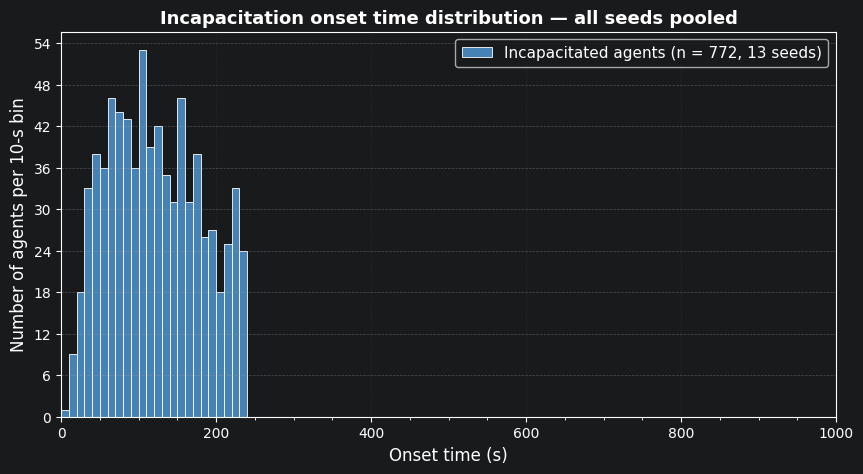

In [19]:
t_min = onset_df["onset_time_s"].min()
t_max = onset_df["onset_time_s"].max()
bins  = np.arange(np.floor(t_min / BIN_WIDTH) * BIN_WIDTH,
                  t_max + BIN_WIDTH,
                  BIN_WIDTH)

fig, ax = plt.subplots(figsize=(10, 5))

counts, edges, patches = ax.hist(
    onset_df["onset_time_s"],
    bins=bins,
    color="steelblue",
    edgecolor="white",
    linewidth=0.6,
    label=f"Incapacitated agents (n = {n_onset}, {n_seeds} seeds)",
)

ax.set_xlabel("Onset time (s)", fontsize=12)
ax.set_ylabel(f"Number of agents per {BIN_WIDTH}-s bin", fontsize=12)
ax.set_title(TITLE, fontsize=13, fontweight="bold")
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.35, linestyle="--")
ax.grid(axis="x", alpha=0.15, linestyle=":")
if X_MAX is not None:
    plt.xlim(0, X_MAX)

fig.tight_layout()
plt.savefig("onset_histogram_multiseed.png", dpi=150)
plt.show()

## 4 — Cumulative incapacitation curve (pooled)

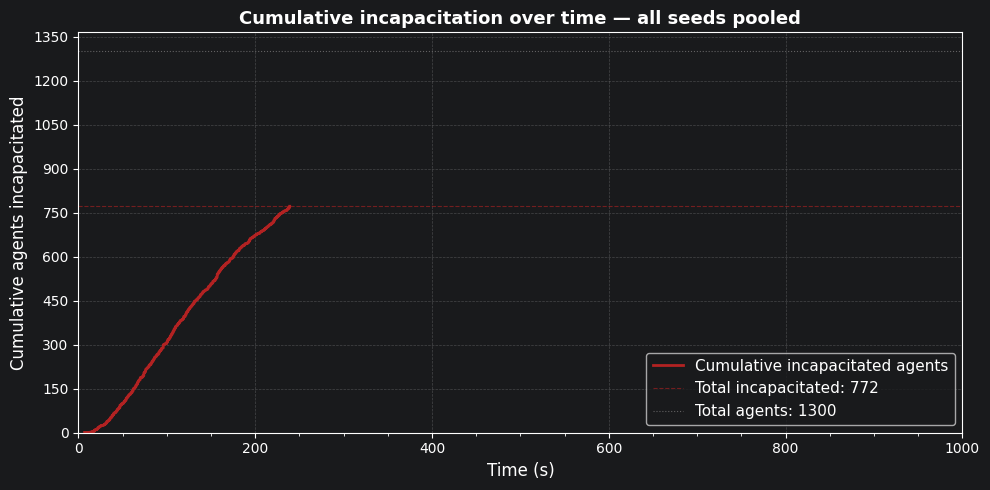

In [20]:
t_sorted = onset_df["onset_time_s"].sort_values().values
cumulative = np.arange(1, len(t_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.step(t_sorted, cumulative, where="post", color="firebrick", linewidth=2,
        label="Cumulative incapacitated agents")
ax.axhline(n_onset, color="firebrick", linestyle="--", linewidth=0.8, alpha=0.6,
           label=f"Total incapacitated: {n_onset}")
ax.axhline(n_total, color="grey", linestyle=":", linewidth=0.8, alpha=0.7,
           label=f"Total agents: {n_total}")

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Cumulative agents incapacitated", fontsize=12)
ax.set_title("Cumulative incapacitation over time — all seeds pooled", fontsize=13, fontweight="bold")
ax.set_ylim(0, n_total * 1.05)
if X_MAX is not None:
    ax.set_xlim(0, X_MAX)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle="--")

fig.tight_layout()
plt.savefig("onset_cumulative_multiseed.png", dpi=150)
plt.show()

## 5 — Summary statistics (pooled)

In [21]:
stats = onset_df["onset_time_s"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
print(stats.to_string())

count    772.000000
mean     121.839378
std       59.746504
min        7.000000
10%       44.000000
25%       73.000000
50%      117.500000
75%      168.250000
90%      211.000000
max      239.000000


## 6 — Theoretical vs. empirical incapacitation threshold (pooled)

Probabilistic mode draws each agent's own FED incapacitation threshold from
`D_incap = fed_threshold * exp(susceptibility_sigma * Z)`, `Z ~ N(0,1)` — a log-normal
with median `fed_threshold`. That per-agent draw isn't stored in the CSV, but it's
recoverable: incapacitation triggers exactly when `fed_cumulative >= D_incap`, so each
agent's `fed_cumulative` at their onset row **is** their threshold (to within one timestep).

Set `FED_THRESHOLD` / `SUSCEPTIBILITY_SIGMA` below to match what the runs were launched with
(webapp/CLI defaults: 1.0 / 0.94) — these aren't stored in the output, so they have to be
supplied here. Leave `SUSCEPTIBILITY_SIGMA = None` if the runs used deterministic mode.

In [22]:
from scipy import stats as sps

FED_THRESHOLD = 1.0          # median threshold used for these runs
SUSCEPTIBILITY_SIGMA = 0.94  # log-scale sigma; None => deterministic mode (skip overlay)

In [23]:
# Recover each agent's empirical threshold: fed_cumulative at their onset row,
# pooled across every seed's run (agent ids repeat across seeds, so process per-run).
# Agents who never flip to incapacitated are tracked separately (see below) — their
# true threshold is unknown, only that it exceeds whatever FED they reached.
def thresholds_for_run(path, seed):
    df = pd.read_csv(path)
    rows = []
    never_max = []
    for agent_id, group in df.groupby("agent_id"):
        group = group.sort_values("time_s")
        incap = group["incapacitated"].astype(bool)
        mask = incap & ~incap.shift(1, fill_value=False)
        onset_rows = group[mask]
        if not onset_rows.empty:
            rows.append({
                "seed": seed,
                "agent_id": agent_id,
                "empirical_threshold": onset_rows["fed_cumulative"].iloc[0],
            })
        else:
            never_max.append(group["fed_cumulative"].max())
    return pd.DataFrame(rows), never_max

threshold_parts = []
never_incap_max_fed = []
for p in csv_paths:
    part, never_max = thresholds_for_run(p, seed_label(p))
    threshold_parts.append(part)
    never_incap_max_fed.extend(never_max)

threshold_df = pd.concat(threshold_parts, ignore_index=True)
print(f"Recovered thresholds for {len(threshold_df)} / {n_total} agents across {n_seeds} seeds")
threshold_df["empirical_threshold"].describe()

Recovered thresholds for 772 / 1300 agents across 13 seeds


count    772.000000
mean       0.652154
std        0.319798
min        0.037468
25%        0.390738
50%        0.628928
75%        0.900571
max        1.279266
Name: empirical_threshold, dtype: float64

### Why this needs right-truncation, not a raw overlay

`empirical_threshold` only exists for agents that actually flipped `incapacitated = True`.
Any agent whose *drawn* threshold happened to land above the maximum FED this exposure
ever delivers is invisible to this recovery method — it never crosses, so there's no onset
row to read a threshold off of. That's **right-truncation**: the sample silently excludes
everything above a ceiling, rather than partially recording it (which would instead be
*censoring*, e.g. "threshold >= ceiling" — not the case here, since we simply have no row).

Comparing that truncated sample to the raw, unconditional log-normal will always look wrong
in the tail — not because the sampling code is broken, but because this scenario's exposure
never gets severe/long enough to expose agents past the ceiling. The statistically correct
comparison is the log-normal **renormalized over the observable range**:

$$f_{	ext{trunc}}(x) = \dfrac{f(x)}{F(	ext{ceiling})}, \quad x \le 	ext{ceiling}$$

using the parent log-normal's PDF `f` and CDF `F`. This is the standard right-truncated-
distribution technique from reliability/survival analysis, applied here under the
assumption (reasonable for a homogeneous-exposure scenario) that every agent shares roughly
the same FED ceiling — for scenarios with widely varying per-agent exposure, a single global
ceiling is only an approximation, since different agents may have genuinely different
individual ceilings depending on their trajectory relative to the fire.

In [24]:
n_never = len(never_incap_max_fed)
if n_never:
    fed_ceiling = max(never_incap_max_fed)
    print(f"Censored (never crossed their threshold): {n_never} / {n_total} "
          f"({100 * n_never / n_total:.1f}%)")
    print(f"FED ceiling this exposure ever delivers:    {fed_ceiling:.3f}")
else:
    fed_ceiling = None
    print("No censoring — every agent crossed their threshold; raw log-normal is a valid comparison.")

Censored (never crossed their threshold): 528 / 1300 (40.6%)
FED ceiling this exposure ever delivers:    1.279


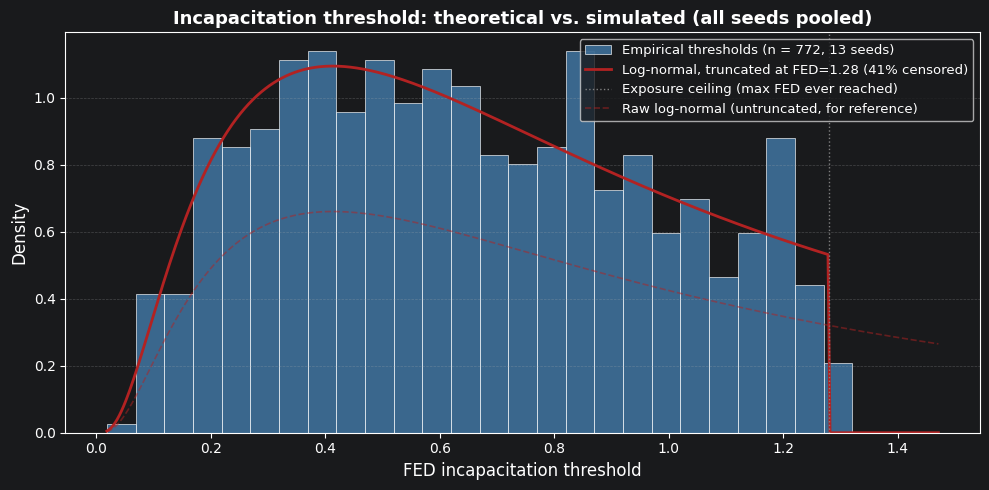

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = threshold_df["empirical_threshold"].values
hi = max(vals.max(), fed_ceiling or 0) * 1.15
bins = np.linspace(max(vals.min() * 0.5, 1e-6), hi, 30)

ax.hist(vals, bins=bins, density=True, color="steelblue", edgecolor="white",
        linewidth=0.6, alpha=0.75, label=f"Empirical thresholds (n = {len(vals)}, {n_seeds} seeds)")

if SUSCEPTIBILITY_SIGMA:
    dist = sps.lognorm(s=SUSCEPTIBILITY_SIGMA, scale=FED_THRESHOLD)
    x = np.linspace(bins[0], bins[-1], 400)

    if fed_ceiling is not None:
        norm = dist.cdf(fed_ceiling)
        pdf_trunc = np.where(x <= fed_ceiling, dist.pdf(x) / norm, 0.0)
        ax.plot(x, pdf_trunc, color="firebrick", linewidth=2,
                label=f"Log-normal, truncated at FED={fed_ceiling:.2f} ({100*n_never/n_total:.0f}% censored)")
        ax.axvline(fed_ceiling, color="grey", linestyle=":", linewidth=1,
                    label="Exposure ceiling (max FED ever reached)")
        ax.plot(x, dist.pdf(x), color="firebrick", linewidth=1.2, linestyle="--", alpha=0.5,
                label="Raw log-normal (untruncated, for reference)")
    else:
        ax.plot(x, dist.pdf(x), color="firebrick", linewidth=2,
                label=f"Theoretical log-normal (median={FED_THRESHOLD}, sigma={SUSCEPTIBILITY_SIGMA})")

ax.set_xlabel("FED incapacitation threshold", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Incapacitation threshold: theoretical vs. simulated (all seeds pooled)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9.5)
ax.grid(axis="y", alpha=0.3, linestyle="--")

fig.tight_layout()
plt.savefig("threshold_distribution_multiseed.png", dpi=150)
plt.show()